# MHT-CET College Predictor
### Engineering CAP Round 1 — cutoff analysis & seat-allocation predictor

Given a student's percentile, social category, gender, home-university status, and
optional branch/region filters, predict the colleges and branches they can realistically
expect a seat in.

**Data.** Official MHT-CET CAP Round 1 cutoff lists for **2022, 2023, 2024**. Each record is one
*(college, branch, seat-type, reservation category)* with the **closing percentile** (percentile of the
last candidate admitted) and **closing merit number**.

**Method.** Cutoffs are projected to the next year using the per-option year-over-year trend (capped to a
realistic range), then options are bucketed into Safe / Target / Reach against the student's percentile.
A gradient-boosted model additionally learns the cutoff surface for imputation and comparison.


## 1. Setup

In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True

## 2. Load the data + tag regions

CSV files live in `data/` (named like `mhtcet_2024_cap1_cutoffs.csv`). The loader picks up every year it
finds and stacks them with a `year` column. The first two digits of the college code are the official
MHT-CET admission region; a city-name fallback covers a few special university codes.

In [2]:
REGION_BY_PREFIX = {
    '01': 'Amravati', '02': 'Chhatrapati Sambhajinagar', '03': 'Mumbai',
    '04': 'Nagpur',   '05': 'Nashik',                    '06': 'Pune',
}
CITY_REGION = {
    'navi mumbai': 'Mumbai', 'mumbai': 'Mumbai', 'pune': 'Pune', 'coep': 'Pune',
    'nagpur': 'Nagpur', 'nashik': 'Nashik', 'amravati': 'Amravati',
    'sambhajinagar': 'Chhatrapati Sambhajinagar', 'aurangabad': 'Chhatrapati Sambhajinagar',
}

def add_region(f):
    f = f.copy()
    f['region'] = f['college_code'].astype(str).str.zfill(5).str[:2].map(REGION_BY_PREFIX)
    mask = f['region'].isna()
    def by_city(name):
        n = str(name).lower()
        for k, v in CITY_REGION.items():
            if k in n:
                return v
        return 'Other'
    f.loc[mask, 'region'] = f.loc[mask, 'college_name'].apply(by_city)
    return f

def load_all_years():
    paths = (sorted(glob.glob('data/mhtcet_*_cap1_cutoffs.csv'))
             or sorted(glob.glob('mhtcet_*_cap1_cutoffs.csv')))
    if not paths:
        raise FileNotFoundError("No mhtcet_*_cap1_cutoffs.csv found in ./data/ or ./")
    frames = []
    for path in paths:
        m = re.search(r'(20\d{2})', os.path.basename(path))
        if not m:
            continue
        d = pd.read_csv(path, dtype={'college_code': str, 'branch_code': str})
        d['year'] = int(m.group(1))
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df['closing_percentile'] = pd.to_numeric(df['closing_percentile'], errors='coerce')
    df['closing_merit_no']   = pd.to_numeric(df['closing_merit_no'], errors='coerce')
    return add_region(df)

df = load_all_years()
years = sorted(df['year'].unique())
print('Years:', years, '| Rows:', len(df),
      '| Colleges:', df.college_code.nunique(),
      '| Regions:', sorted(df.region.unique()))
df.head()

Years: [np.int64(2022), np.int64(2023), np.int64(2024)] | Rows: 76497 | Colleges: 357 | Regions: ['Amravati', 'Chhatrapati Sambhajinagar', 'Mumbai', 'Nagpur', 'Nashik', 'Other', 'Pune']


,college_code,college_name,branch_code,branch_name,seat_type,category,closing_merit_no,closing_percentile,year,region
0,01002,"Government College of Engineering, Amravati",0100219110,Civil Engineering,State Level,GOPENS,40678.0,77.849577,2022,Amravati
1,01002,"Government College of Engineering, Amravati",0100219110,Civil Engineering,State Level,GSCS,55830.0,68.298536,2022,Amravati
2,01002,"Government College of Engineering, Amravati",0100219110,Civil Engineering,State Level,GSTS,86718.0,43.316750,2022,Amravati
3,01002,"Government College of Engineering, Amravati",0100219110,Civil Engineering,State Level,GVJS,45691.0,74.510640,2022,Amravati
4,01002,"Government College of Engineering, Amravati",0100219110,Civil Engineering,State Level,GNT1S,41586.0,77.066692,2022,Amravati


## 3. Reservation-category codes

Each `category` packs three pieces: **gender** (first letter — G = General/gender-neutral, L = Ladies),
**social category** (middle — OPEN, SC, ST, OBC, EWS, VJ, NT1/2/3, SEBC…), and **seat scope**
(last letter — S = State, H = Home university, O = Other-than-home). E.g. `GOPENH` = General-Open, Home seat.

`eligible_categories` turns a student profile into the set of codes they may compete for (reserved
candidates also compete for OPEN; females compete for both Ladies and gender-neutral seats).

In [3]:
SOCIAL_TO_CODE = {
    'OPEN':'OPEN','SC':'SC','ST':'ST','OBC':'OBC','EWS':'EWS',
    'VJ':'VJ','VJA':'VJ','DT':'VJ','NT1':'NT1','NT2':'NT2','NT3':'NT3','SEBC':'SEBC',
}

def eligible_categories(social='OPEN', gender='male', home_university=True, df=df):
    social = social.upper()
    mids = {SOCIAL_TO_CODE.get(social, 'OPEN'), 'OPEN'}
    if social == 'EWS':
        mids = {'EWS', 'OPEN'}
    genders = ['G', 'L'] if gender.lower().startswith('f') else ['G']
    scopes = ['S', 'H'] if home_university else ['S', 'O']
    wanted = {f'{g}{m}{s}' for g in genders for m in mids for s in scopes}
    return sorted(wanted & set(df['category'].unique()))

eligible_categories('OBC', 'female', home_university=True)

['GOBCH', 'GOBCS', 'GOPENH', 'GOPENS', 'LOBCH', 'LOBCS', 'LOPENH', 'LOPENS']

## 4. Exploratory analysis

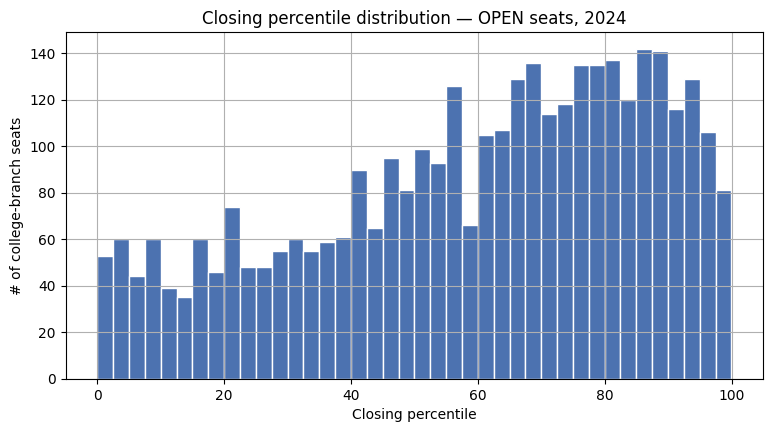

In [4]:
latest = max(years)
cur = df[df.year == latest]
opens = cur[cur.category.isin(['GOPENS','GOPENH','GOPENO'])]

plt.hist(opens.closing_percentile.dropna(), bins=40, color='#4C72B0', edgecolor='white')
plt.title(f'Closing percentile distribution — OPEN seats, {latest}')
plt.xlabel('Closing percentile'); plt.ylabel('# of college-branch seats'); plt.show()

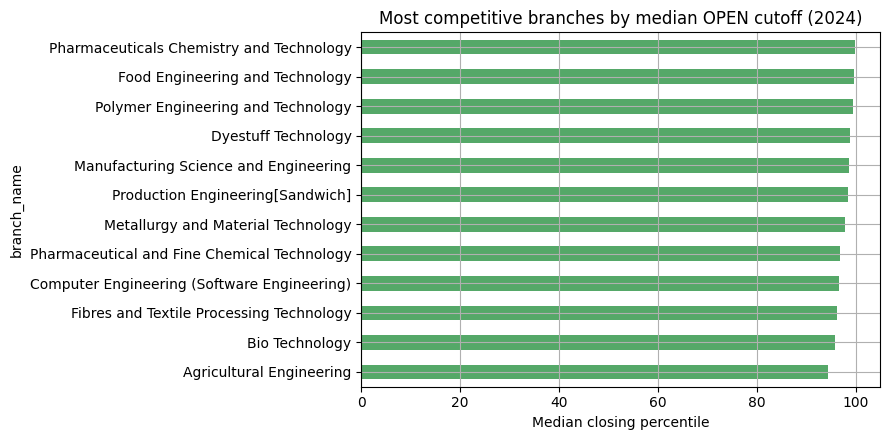

In [5]:
top_branch = (opens.groupby('branch_name')['closing_percentile']
                   .median().sort_values(ascending=False).head(12))
top_branch.iloc[::-1].plot(kind='barh', color='#55A868')
plt.title(f'Most competitive branches by median OPEN cutoff ({latest})')
plt.xlabel('Median closing percentile'); plt.tight_layout(); plt.show()

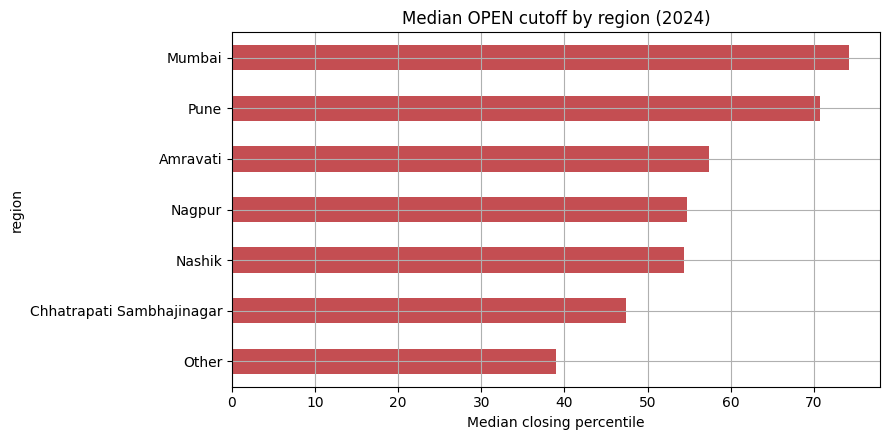

In [6]:
# Region competitiveness
reg = (opens.groupby('region')['closing_percentile'].median().sort_values())
reg.plot(kind='barh', color='#C44E52')
plt.title(f'Median OPEN cutoff by region ({latest})')
plt.xlabel('Median closing percentile'); plt.tight_layout(); plt.show()

## 5. Year-over-year trend & next-year projection

For every *(college, branch, category)* we estimate the typical yearly drift (median of year-over-year
changes, capped to ±8 points so sparse histories don't produce wild numbers) and project the next-year
expected cutoff. With one year loaded this falls back to last year's value.

In [7]:
KEY = ['college_code','branch_code','category']

def build_expected_cutoff(df):
    latest = max(df.year.unique())
    if df.year.nunique() == 1:
        out = df[df.year == latest].copy()
        out['expected_cutoff'] = out['closing_percentile']
        out['trend'] = 0.0
        return out
    piv = df.pivot_table(index=KEY, columns='year', values='closing_percentile')
    yrs = sorted(piv.columns)
    drift = piv[yrs].diff(axis=1).median(axis=1).clip(-8, 8)
    last_val = piv[yrs].ffill(axis=1)[yrs[-1]]
    expected = (last_val + drift).clip(0, 100)
    proj = pd.DataFrame({'expected_cutoff': expected, 'trend': drift}).reset_index()
    meta = (df[df.year == latest][KEY + ['college_name','branch_name','seat_type','region']]
            .drop_duplicates(KEY))
    out = proj.merge(meta, on=KEY, how='left')
    out['closing_percentile'] = last_val.reindex(out.set_index(KEY).index).values
    return out

expected = build_expected_cutoff(df)
print(f"Expected-cutoff table: {len(expected)} options "
      f"({'projected from trend' if df.year.nunique()>1 else 'latest year only'}).")
expected.head()

Expected-cutoff table: 38162 options (projected from trend).


,college_code,branch_code,category,expected_cutoff,trend,college_name,branch_name,seat_type,region,closing_percentile
0,01002,0100219110,DEFOBCS,NaN,NaN,"Government College of Engineering, Amravati",Civil Engineering,State Level,Amravati,47.984280
1,01002,0100219110,DEFOPENS,75.045836,8.000000,"Government College of Engineering, Amravati",Civil Engineering,State Level,Amravati,67.045836
2,01002,0100219110,DEFROBCS,NaN,NaN,NaN,NaN,NaN,NaN,32.499271
3,01002,0100219110,DEFRSEBCS,NaN,NaN,"Government College of Engineering, Amravati",Civil Engineering,State Level,Amravati,50.634076
4,01002,0100219110,EWS,64.171483,-2.014033,"Government College of Engineering, Amravati",Civil Engineering,State Level,Amravati,66.185516


## 6. The college predictor

Returns eligible options within reach, bucketed into **Safe / Target / Reach**, sorted with the most
competitive (highest cutoff) first. Optional `branch` (string or list) and `region` filters.

In [8]:
def predict_colleges(percentile, social='OPEN', gender='male', home_university=True,
                     branch=None, region=None, reach=1.0, safe=4.0,
                     ascending=False, top_n=None, table=expected):
    """Predict reachable college-branch options for a student.

    branch : str or list of substrings, e.g. ['Computer Engineering', 'Information Technology']
    region : 'Pune', 'Mumbai', 'Nagpur', 'Nashik', 'Amravati', 'Chhatrapati Sambhajinagar'
    ascending : False -> most competitive first; True -> easiest-to-get first
    """
    codes = eligible_categories(social, gender, home_university)
    d = table[table.category.isin(codes) & table.expected_cutoff.notna()].copy()

    if branch:
        branches = [branch] if isinstance(branch, str) else list(branch)
        pattern = '|'.join(re.escape(b) for b in branches)
        d = d[d.branch_name.str.contains(pattern, case=False, na=False, regex=True)]
    if region:
        d = d[d.region.str.contains(region, case=False, na=False)]

    d = (d.sort_values('expected_cutoff')
           .groupby(['college_code', 'branch_code'], as_index=False).first())
    d['margin'] = percentile - d['expected_cutoff']
    d = d[d['margin'] >= -reach]

    def band(m):
        if m >= safe: return '1. Safe'
        if m >= 0:    return '2. Target'
        return '3. Reach'
    d['chance'] = d['margin'].apply(band)

    cols = ['chance','college_name','region','branch_name','category','expected_cutoff','margin']
    if 'trend' in d.columns:
        cols.append('trend')
    out = d[cols].sort_values('expected_cutoff', ascending=ascending).reset_index(drop=True)
    out['expected_cutoff'] = out['expected_cutoff'].round(3)
    out['margin'] = out['margin'].round(3)
    return out.head(top_n) if top_n else out

### Example — 99-percentile OPEN male, CS/IT/Mechanical in the Pune region

In [9]:
predict_colleges(
    percentile=99.0,
    social='OPEN',
    gender='male',
    branch=['Information Technology', 'Computer Engineering', 'Mechanical Engineering'],
    region='Pune',
    home_university=True,
).head(15)

,chance,college_name,region,branch_name,category,expected_cutoff,margin,trend
0,3. Reach,Pimpri Chinchwad Education Trust's Pimpri Chin...,Pune,Mechanical Engineering,GOPENH,100.000,-1.000,8.000000
1,3. Reach,Pune Vidyarthi Griha's College of Engineering ...,Pune,Mechanical Engineering,GOPENH,100.000,-1.000,7.628140
2,3. Reach,"Walchand College of Engineering, Sangli",Pune,Mechanical Engineering,GOPENS,99.215,-0.215,1.001995
3,2. Target,Bansilal Ramnath Agarawal Charitable Trust's V...,Pune,Computer Engineering,GOPENS,98.993,0.007,-0.009657
4,2. Target,"Walchand College of Engineering, Sangli",Pune,Information Technology,GOPENS,98.960,0.040,-0.058116
5,2. Target,"Pimpri Chinchwad Education Trust, Pimpri Chinc...",Pune,Information Technology,GOPENS,98.641,0.359,0.137693
6,2. Target,Bansilal Ramnath Agarawal Charitable Trust's V...,Pune,Information Technology,GOPENS,98.575,0.425,-0.036835
7,2. Target,"Pimpri Chinchwad Education Trust, Pimpri Chinc...",Pune,Computer Engineering,GOPENS,98.421,0.579,-0.042547
8,2. Target,"Pimpri Chinchwad Education Trust, Pimpri Chinc...",Pune,Mechanical Engineering,GOPENS,98.220,0.780,2.756512
9,2. Target,Pune Vidyarthi Griha's College of Engineering ...,Pune,Computer Engineering,GOPENH,97.759,1.241,0.002770


### Try your own profile

In [10]:
predict_colleges(
    percentile=88.0,
    social='OPEN',          # OPEN, SC, ST, OBC, EWS, VJ, NT1, NT2, NT3, SEBC
    gender='male',          # 'male' or 'female'
    home_university=True,   # True if applying within your own university region
    branch=None,            # e.g. 'Computer' or ['Civil Engineering', 'Information Technology']
    region=None,            # e.g. 'Pune'
).head(30)

,chance,college_name,region,branch_name,category,expected_cutoff,margin,trend
0,3. Reach,"Dhole Patil Education Society, Dhole Patil Col...",Pune,Computer Engineering,GOPENH,88.990,-0.990,1.888305
1,3. Reach,K. E. Society's Rajarambapu Institute of Techn...,Pune,Electrical Engineering,GOPENS,88.986,-0.986,4.474778
2,3. Reach,Ankush Shikshan Sanstha's G.H.Raisoni College ...,Nagpur,Computer Science and Engineering (Cyber Security),GOPENS,88.887,-0.887,1.802366
3,3. Reach,NaN,NaN,NaN,GOPENH,88.876,-0.876,3.922780
4,3. Reach,"Walchand Institute of Technology, Solapur",Pune,Electronics and Telecommunication Engg,GOPENS,88.842,-0.842,4.035792
5,3. Reach,"Sinhgad Academy of Engineering, Kondhwa (BK) K...",Pune,Information Technology,GOPENH,88.826,-0.826,1.531028
6,3. Reach,Ankush Shikshan Sanstha's G.H.Raisoni College ...,Nagpur,Computer Science and Engineering (IoT),GOPENS,88.779,-0.779,2.635754
7,3. Reach,"Government College of Engineering, Jalgaon",Nashik,Electronics and Telecommunication Engg,GOPENS,88.772,-0.772,1.875261
8,3. Reach,All India Shri Shivaji Memorial Society's Coll...,Pune,Chemical Engineering,GOPENH,88.741,-0.741,8.000000
9,3. Reach,Shivnagar Vidya Prasarak Mandal's College of E...,Pune,Computer Engineering,GOPENH,88.668,-0.668,2.093299


## 7. ML model — learning the cutoff surface

Predict closing percentile from (college, branch, social, scope, gender, year) with gradient-boosted
trees. Useful for imputing missing combinations and, with `year` as a feature, model-based projection.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score

m = df.dropna(subset=['closing_percentile']).copy()
m['scope']  = m['category'].str[-1]
m['social'] = m['category'].str.replace(r'^[GL]', '', regex=True).str[:-1]
m['gender_seat'] = m['category'].str[0]

features = ['college_name','branch_name','social','scope','gender_seat','year']
X, y = m[features], m['closing_percentile']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

reg = Pipeline([
    ('pre', ColumnTransformer([('cat',
        OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), features)])),
    ('gb', HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08, random_state=42)),
])
reg.fit(Xtr, ytr)
pred = reg.predict(Xte)
print(f"MAE: {mean_absolute_error(yte, pred):.2f} percentile points")
print(f"R2 : {r2_score(yte, pred):.3f}")

MAE: 12.32 percentile points
R2 : 0.657


## 8. Limitations & next steps

- Eligibility is simplified (no minority/PWD/Defence/TFW sub-quotas; extend `eligible_categories` if needed).
- CAP Round 1 only — later rounds shift seats, so treat "Reach" generously.
- `region` is the **college location**, separate from your **home-university** seat eligibility.
- Trend projection is rough on 3 years; more years would let you fit and validate it.
- Possible extensions: Streamlit front-end, clustering colleges by cutoff profile, calibrating bands
  against actual Round-2 movement.

See `scripts/parse_cutoff_pdf.py` for the parser that produced the CSVs from the official PDFs.